# NASA C-MAPSS FD001 — Tree-Based RUL Prediction

**Author:** Pallavi 

---

## Objective

In this notebook, I will investigate whether tree-based regression models can capture nonlinear relationships between engine sensor measurements and Remaining Useful Life (RUL).

The baseline Linear Regression model achieved an MAE of 25.16 cycles, RMSE of 31.66 cycles, and R² of 0.768.

I will use these results as the benchmark and evaluate whether a tree-based approach can improve the prediction performance.

In [1]:
# Importing required libraries

import sys
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("../")

from src.preprocessing import load_training_data, remove_constant_features

In [3]:
# Loading and preparing the training data

train_df = load_training_data("../data/raw/train_FD001.txt")

train_df, constant_columns = remove_constant_features(train_df)

train_df.head()

,unit_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


## Preparing Training and Validation Data

I will use the same engine-level validation approach established earlier so that the Random Forest can be compared fairly with the Linear Regression baseline.

In [4]:
# Splitting engines into training and validation sets

import numpy as np

units = train_df["unit_id"].unique()

np.random.seed(42)
np.random.shuffle(units)

train_units = units[:80]
val_units = units[80:]

train_data = train_df[train_df["unit_id"].isin(train_units)]
val_data = train_df[train_df["unit_id"].isin(val_units)]

X_train = train_data.drop(columns=["unit_id", "RUL"])
y_train = train_data["RUL"]

X_val = val_data.drop(columns=["unit_id", "RUL"])
y_val = val_data["RUL"]

print("Training engines:", train_data["unit_id"].nunique())
print("Validation engines:", val_data["unit_id"].nunique())

Training engines: 80
Validation engines: 20


## Training the Random Forest Model

Random Forest combines predictions from many decision trees. Unlike Linear Regression, it can learn nonlinear relationships between sensor measurements and RUL.

I will start with a basic Random Forest model and use the validation results to determine whether this approach improves on the baseline.

In [5]:
# Training the Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluating the Random Forest Model

I will evaluate the Random Forest using the same validation data and metrics used for Linear Regression.

In [6]:
# Evaluating Random Forest

rf_pred = rf_model.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = mean_squared_error(y_val, rf_pred) ** 0.5
rf_r2 = r2_score(y_val, rf_pred)

print(f"MAE : {rf_mae:.2f} cycles")
print(f"RMSE: {rf_rmse:.2f} cycles")
print(f"R²  : {rf_r2:.3f}")

MAE : 28.00 cycles
RMSE: 39.46 cycles
R²  : 0.698


## Comparing Linear Regression and Random Forest

The Random Forest model was evaluated using the same validation engines as the Linear Regression baseline.

Random Forest achieved an MAE of 28.00 cycles, RMSE of 39.46 cycles, and R² of 0.698.

Compared with the Linear Regression baseline, Random Forest produced higher errors and a lower R².

Therefore, Random Forest does not improve the current RUL prediction performance on the validation data.

For the next stage, I will retain Linear Regression as the current benchmark and investigate whether another tree-based approach can provide better performance.

In [7]:
# Checking Random Forest feature importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

cycle        0.547722
sensor_11    0.144816
sensor_9     0.044502
sensor_12    0.030891
sensor_4     0.028983
sensor_15    0.023613
sensor_14    0.023178
sensor_7     0.023152
sensor_21    0.019790
sensor_3     0.018462
sensor_2     0.018262
sensor_20    0.015318
setting_1    0.015291
sensor_13    0.014927
sensor_8     0.014901
setting_2    0.009414
sensor_17    0.006255
sensor_6     0.000524
dtype: float64

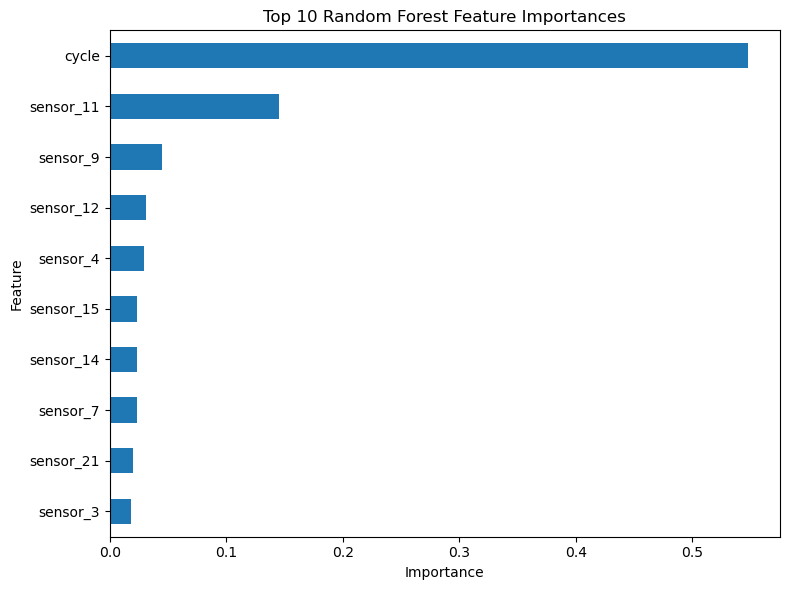

In [8]:
# Plotting Random Forest feature importance

plt.figure(figsize=(8, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../reports/figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Findings

The Random Forest model was tested to determine whether a nonlinear tree-based approach could improve the Linear Regression baseline.

Random Forest achieved:

- MAE: 28.00 cycles
- RMSE: 39.46 cycles
- R²: 0.698

The Linear Regression baseline performed better with:

- MAE: 25.16 cycles
- RMSE: 31.66 cycles
- R²: 0.768

Therefore, Random Forest did not improve the validation performance for this experiment. The Linear Regression model remains the current best-performing model.

The feature importance analysis also provided insight into which sensor measurements were most useful to the Random Forest model.

Since model performance should be driven by validation results rather than model complexity, I will retain Linear Regression as the benchmark and test another modeling approach in the next stage.

In [9]:
# Comparing the main models tested so far

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Random Forest"
    ],
    "MAE": [
        25.16,
        25.16,
        25.15,
        28.00
    ],
    "RMSE": [
        31.66,
        31.66,
        31.66,
        39.46
    ],
    "R2": [
        0.768,
        0.768,
        0.767,
        0.698
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,25.16,31.66,0.768
1,Ridge,25.16,31.66,0.768
2,Lasso,25.15,31.66,0.767
3,Random Forest,28.00,39.46,0.698


In [13]:
# Comparing a few Random Forest configurations

rf_models = {
    "RF_200": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "RF_300_depth20": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),

    "RF_300_leaf2": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

rf_results = []

for name, model in rf_models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    rmse = mean_squared_error(y_val, pred) ** 0.5
    r2 = r2_score(y_val, pred)

    rf_results.append([name, mae, rmse, r2])

rf_results_df = pd.DataFrame(
    rf_results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

rf_results_df

,Model,MAE,RMSE,R2
0,RF_200,27.995858,39.459590,0.698376
1,RF_300_depth20,27.979137,39.406290,0.699190
2,RF_300_leaf2,27.868432,39.342104,0.700169


## Random Forest Tuning Finding

A small hyperparameter experiment was performed to determine whether the Random Forest model could be improved.

The best configuration used 300 trees with `min_samples_leaf=2`, achieving an MAE of 27.87 cycles, RMSE of 39.34 cycles, and R² of 0.700.

Although this was a small improvement over the initial Random Forest model, it remained substantially worse than the Linear Regression baseline.

Therefore, further Random Forest tuning is unlikely to be the most useful direction for this project. I will retain Linear Regression as the current benchmark and move to a different modeling approach.